In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
from tensorflow.keras.utils import image_dataset_from_directory
import tensorflow_addons as tfa


c:\Users\ANURAG KOKITKAR\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\ANURAG KOKITKAR\AppData\Local\Programs\Python\Python310\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
I

In [26]:
training_set = image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 76515 files belonging to 4 classes.


In [27]:
validation_set = image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 21861 files belonging to 4 classes.


In [28]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [29]:
INPUT_SHAPE = (224, 224, 3)

In [30]:
mobnet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling=None,
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=True,
    # name="MobileNetV3Large",
)

In [31]:
#mobnet.trainable = False #--used to freeze weights of this pretrained model 

In [32]:
model = tf.keras.models.Sequential()

In [33]:
model.add(tf.keras.Input(shape=INPUT_SHAPE))

In [35]:
model.add(mobnet)

In [40]:
model.add(tf.keras.layers.Dense(units = 4,activation='softmax'))

In [41]:
metrics_list = ['accuracy',
                tf.keras.metrics.F1Score()]

In [42]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=metrics_list)

In [15]:
model.summary()

NameError: name 'model' is not defined

In [44]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=15)

Epoch 1/15
2392/2392 [==============================] - 987s 411ms/step - loss: 1.1454 - accuracy: 0.8422 - f1_score: 0.5950 - val_loss: 0.9870 - val_accuracy: 0.8807 - val_f1_score: 0.6714
Epoch 2/15
2392/2392 [==============================] - 1140s 477ms/step - loss: 0.8648 - accuracy: 0.8877 - f1_score: 0.6841 - val_loss: 0.7606 - val_accuracy: 0.8642 - val_f1_score: 0.6772
Epoch 3/15
2392/2392 [==============================] - 1151s 481ms/step - loss: 0.6702 - accuracy: 0.8858 - f1_score: 0.6883 - val_loss: 0.6100 - val_accuracy: 0.8930 - val_f1_score: 0.6908
Epoch 4/15
2392/2392 [==============================] - 1434s 599ms/step - loss: 0.5357 - accuracy: 0.9060 - f1_score: 0.7901 - val_loss: 0.4866 - val_accuracy: 0.9312 - val_f1_score: 0.8855
Epoch 5/15
2392/2392 [==============================] - 1414s 591ms/step - loss: 0.4321 - accuracy: 0.9422 - f1_score: 0.8972 - val_loss: 0.3957 - val_accuracy: 0.9452 - val_f1_score: 0.9002
Epoch 6/15
2392/2392 [========================

In [45]:
model.save("Trained_Model.h5")

/Users/animesh/anaconda3/envs/tensorflow/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [46]:
model.save("Trained_Model.keras")

NameError: name 'training_history' is not defined

In [47]:
# Saving history
with open('Training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

In [12]:
#Reloading History from pickle
import pickle
with open('Training_history.pkl', 'rb') as f:
    load_history = pickle.load(f)
load_history

{'loss': [1.1453802585601807,
  0.8648024201393127,
  0.6702404618263245,
  0.5356669425964355,
  0.4320599436759949,
  0.3479674160480499,
  0.28923746943473816,
  0.24451656639575958,
  0.20830342173576355,
  0.18285790085792542,
  0.1699090301990509,
  0.1487247496843338,
  0.1339232176542282,
  0.12125182151794434,
  0.11251933872699738],
 'accuracy': [0.8422400951385498,
  0.887708306312561,
  0.8857740163803101,
  0.9060314893722534,
  0.9422466158866882,
  0.9499706029891968,
  0.9534600973129272,
  0.9567012786865234,
  0.9605175256729126,
  0.962582528591156,
  0.9621120095252991,
  0.9666078686714172,
  0.9693262577056885,
  0.9716918468475342,
  0.9733254909515381],
 'f1_score': [array([0.8814868 , 0.57463247, 0.00095801, 0.92311895], dtype=float32),
  array([0.9090779 , 0.8804841 , 0.        , 0.94674116], dtype=float32),
  array([0.9392844 , 0.89636165, 0.        , 0.9176859 ], dtype=float32),
  array([0.9481992 , 0.90421456, 0.37415048, 0.9337706 ], dtype=float32),
  arra

In [9]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'val_loss', 'val_accuracy', 'val_f1_score'])

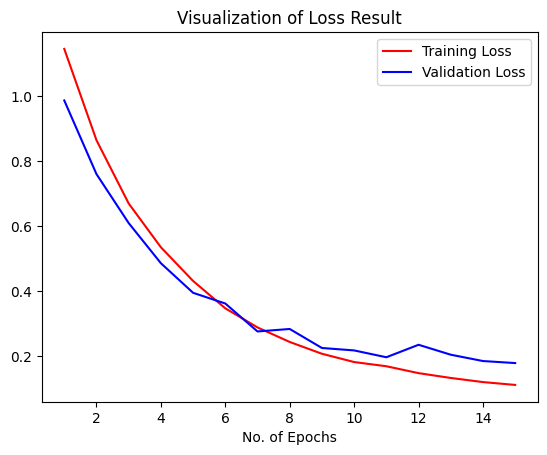

In [13]:
#Loss Visualization
epochs = [i for i in range(1,16)]
plt.plot(epochs,load_history['loss'],color='red',label='Training Loss')
plt.plot(epochs,load_history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

## Model Evaluation


In [19]:
model = tf.keras.models.load_model("Trained_Model.h5", compile=False)

In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy", tfa.metrics.F1Score(num_classes=4, average="macro")]
)

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 MobilenetV3large (Functiona  (None, 1000)             5507432   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 4004      
                                                                 
Total params: 5,511,436
Trainable params: 5,487,036
Non-trainable params: 24,400
_________________________________________________________________


In [21]:
test_set = validation_set = image_dataset_from_directory(
    'test',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=64,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 10933 files belonging to 4 classes.


In [24]:
test_loss,test_acc,f1_score = model.evaluate(test_set)

171/171 [==============================] - 261s 2s/step - loss: 0.1883 - accuracy: 0.9476 - f1_score: 0.9091


In [25]:
test_loss

0.18833328783512115

In [26]:
test_acc

0.9475898742675781

In [27]:
f1_score

0.9091140031814575

In [30]:
##Computing True labels from test set
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [31]:
true_categories

<tf.Tensor: shape=(10933, 4), dtype=float32, numpy=
array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]], dtype=float32)>

In [32]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [33]:
##Computing Predicted labels using test set
predicted_categories = model.predict(test_set)
predicted_categories
Y_pred = tf.argmax(predicted_categories, axis=1)

171/171 [==============================] - 216s 1s/step


In [34]:
Y_true

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

In [35]:
Y_pred

<tf.Tensor: shape=(10933,), dtype=int64, numpy=array([0, 0, 0, ..., 3, 3, 3], dtype=int64)>

### 1. Classification Report

In [36]:
from sklearn.metrics import classification_report
print(classification_report(Y_true,Y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      3746
           1       0.95      0.88      0.91      1161
           2       0.79      0.79      0.79       887
           3       0.96      0.99      0.97      5139

    accuracy                           0.95     10933
   macro avg       0.92      0.90      0.91     10933
weighted avg       0.95      0.95      0.95     10933



### 2. Confusion Matrix

In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_true,Y_pred)
cm

array([[3577,   23,  122,   24],
       [  19, 1020,   13,  109],
       [  75,   10,  700,  102],
       [   4,   17,   55, 5063]], dtype=int64)

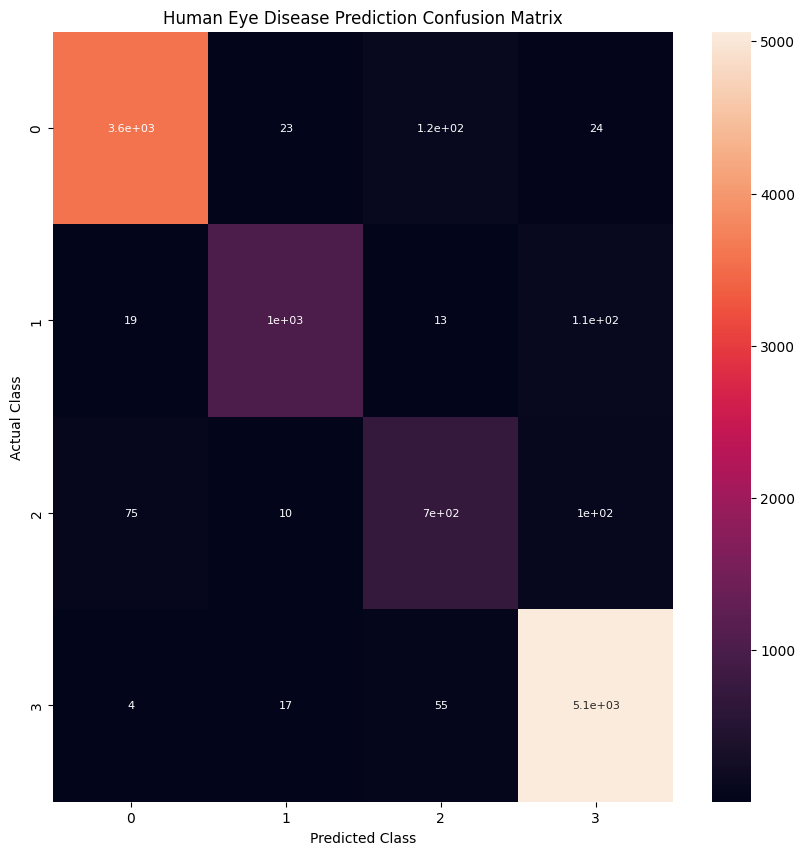

In [38]:
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={"size":8})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Human Eye Disease Prediction Confusion Matrix",fontsize=12)
plt.show()